In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import preprocess_fun as fun

from geomstats.geometry.pre_shape import PreShapeSpace
from geomstats.learning.frechet_mean import FrechetMean
from geomstats.learning.incremental_frechet_mean import IncrementalFrechetMean

In [9]:
glass_data = scipy.io.loadmat('Glass_Shapes.mat')
glasses = np.stack([glass_data['XX'], glass_data['YY']], axis=-1)
glass_uni = fun.obj_align(fun.unify(glasses))

In [10]:
k_landmark = 100
m_ambient = 2
preshape = PreShapeSpace(k_landmark, m_ambient)
preshape.equip_with_group_action('rotations')
preshape.equip_with_quotient()

glass_preshape = preshape.projection(glass_uni)

mean_frechet = FrechetMean(preshape)
mean_incremental = IncrementalFrechetMean(preshape)

glass_mean_frechet = mean_frechet.fit(glass_preshape).estimate_
glass_mean_incremental = mean_incremental.fit(glass_preshape).estimate_
glass_mean_recursive = fun.Rec_Frechet_mean_geom(glass_uni)



(-0.1037022930586414,
 0.10645230352286494,
 -0.11357589431289739,
 0.1272706337348325)

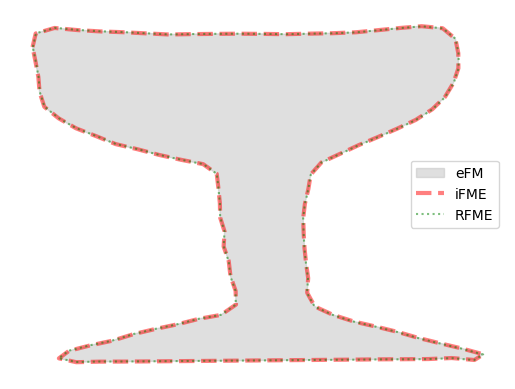

In [11]:
plt.fill(glass_mean_frechet[:,0], glass_mean_frechet[:,1], color = 'silver', alpha = 0.5, label = 'eFM')
plt.plot(glass_mean_incremental[:,0], glass_mean_incremental[:,1], linestyle='--', color = 'r', alpha = 0.5, linewidth = 3, label = 'iFME')
plt.plot(glass_mean_recursive[:,0], glass_mean_recursive[:,1], linestyle=':', color = 'g', alpha = 0.5, label = 'RFME')
plt.legend()
plt.axis('off')

In [12]:
eFM_TE = 0
iFME_TE = 0
RFME_TE = 0
for i in range(glass_preshape.shape[0]):
    eFM_TE += preshape.quotient.metric.dist(glass_mean_frechet, glass_preshape[i])
    iFME_TE += preshape.quotient.metric.dist(glass_mean_incremental, glass_preshape[i])
    RFME_TE += preshape.quotient.metric.dist(glass_mean_recursive, glass_preshape[i])

In [13]:
print('eFM:', eFM_TE, '\niFME:', iFME_TE, '\nRFME:', RFME_TE)

eFM: 0.5290987623896133 
iFME: 0.5289967791863992 
RFME: 0.5289320146357641


In [14]:
print('eFM:', fun.SSE(glass_mean_frechet, glass_preshape), '\niFME:', fun.SSE(glass_mean_incremental, glass_preshape), '\nRFME:', fun.SSE(glass_mean_recursive, glass_preshape))

eFM: 0.04103925151339444 
iFME: 0.04103908338564765 
RFME: 0.04103901499314755
